In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

import warnings
warnings.filterwarnings("ignore")

import scpositioner as sp
from scpositioner.tl import HighResMapper

In [2]:
# demo data can be downloaded via https://drive.google.com/drive/folders/1DntqOZcHvWIsGM990ZPKxUtLhh-p4rw4?usp=sharing
# We used ArchR to extract gene activities score as input matrix. We have included the processed data in demo for convenience. The ArchR tutorial is also provided. 
scatac_adata = sc.read('atac_intestine.h5ad')
scrna_adata = sc.read('rna_intestine.h5ad')
spatial_adata = sc.read('codex_intestine.h5ad')

In [3]:
scatac_adata

AnnData object with n_obs × n_vars = 15756 × 24919
    obs: 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'BlacklistRatio', 'hub_ann', 'CellType'

In [4]:
scrna_adata

AnnData object with n_obs × n_vars = 16905 × 44020
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'pANN', 'seurat_clusters', 'percent.ribo', 'nCount_decontXcounts', 'nFeature_decontXcounts', 'SampleNameOnly', 'SimplifiedSampleName', 'Donor', 'Multiome', 'Location', 'CellTypeInitial', 'CellType'

In [5]:
spatial_adata

AnnData object with n_obs × n_vars = 28136 × 47
    obs: 'x', 'y', 'array', 'Xcorr', 'Ycorr', 'Tissue_location', 'tissue', 'donor', 'unique_region', 'region', 'celltype', 'celltype_em', 'celltype_sub', 'Neighborhood', 'Neigh_sub', 'Neighborhood_Ind', 'NeighInd_sub', 'Community', 'Major Community', 'Tissue Segment', 'CellType'
    uns: 'CellType_colors', 'Tissue_location_colors', 'celltype_colors'
    obsm: 'spatial'

In [6]:
# convert protein names to gene names, here we obtained this conversion table from the original source.
# We have also provided a tutorial to help users convert their proteins.
correspondence = pd.read_csv('protein_gene_conversion.csv')
rna_protein_correspondence = []

for i in range(correspondence.shape[0]):
    curr_protein_name, curr_rna_names = correspondence.iloc[i]
    if curr_protein_name not in spatial_adata.var_names:
        continue
    if curr_rna_names.find('Ignore') != -1: # some correspondence ignored eg. protein isoform to one gene
        continue
    curr_rna_names = curr_rna_names.split('/') # eg. one protein to multiple genes
    for r in curr_rna_names:
        if (r in scatac_adata.var_names) and (r in scrna_adata.var_names):
            rna_protein_correspondence.append([r, curr_protein_name])

rna_protein_correspondence = np.array(rna_protein_correspondence)

spatial_adata = spatial_adata[:, rna_protein_correspondence[:, 1]]
scatac_adata = scatac_adata[:, rna_protein_correspondence[:, 0]]
scrna_adata = scrna_adata[:, rna_protein_correspondence[:, 0]]

spatial_adata.var_names = scrna_adata.var_names.copy()

In [7]:
# For multi-omics datasets, we can map the single cell modality 1 to spatial reference first
mapper_1 = HighResMapper(
            S = scrna_adata.copy(),
            R = spatial_adata.copy(),
            S_celltype_key = 'CellType',
            R_celltype_key = 'CellType',
            normalize = False,
            numItermax = 1e6,
            seed = 0)
rna_mapped = mapper_1.run()

[2026-08-09 17:44:30] Checking single cell AnnData: 16905 cells * 51 features, 10 cell types.
[2026-08-09 17:44:30] Checking spatial reference AnnData: 28136 cells * 51 features; 10 cell types.
[2026-08-09 17:44:30] 10 common cell types found between single cell and spatial reference AnnData.
[2026-08-09 17:44:30] 10 cores are used.
[2026-08-09 17:44:30] Filtering features and cells...
[2026-08-09 17:44:30] Adjusting cell aboundance in single cell AnnData...
[2026-08-09 17:44:30] 48 common features are used for mapping...
[2026-08-09 17:44:30] Adjusting cell aboundance in single cell AnnData...
[2026-08-09 17:44:31] Adjusting cell aboundance in single cell AnnData...
[2026-08-09 17:44:31] Calculating cost matrix (cosine similarity)...
[2026-08-09 17:44:31] Adjusting cell aboundance in single cell AnnData...
[2026-08-09 17:44:31] Adjusting cell aboundance in single cell AnnData...
[2026-08-09 17:44:31] Running optimal transport...
[2026-08-09 17:44:31] Adjusting cell aboundance in singl

In [8]:
# And the map the single cell modality 2 to spatial reference first
mapper_2 = HighResMapper(
            S = scatac_adata.copy(),
            R = spatial_adata.copy(),
            S_celltype_key = 'CellType',
            R_celltype_key = 'CellType',
            normalize = False,
            numItermax = 1e6,
            seed = 0)
atac_mapped = mapper_2.run()

[2026-08-09 17:44:47] Checking single cell AnnData: 15756 cells * 51 features, 10 cell types.
[2026-08-09 17:44:47] Checking spatial reference AnnData: 28136 cells * 51 features; 10 cell types.
[2026-08-09 17:44:47] 10 common cell types found between single cell and spatial reference AnnData.
[2026-08-09 17:44:47] 10 cores are used.
[2026-08-09 17:44:47] Filtering features and cells...
[2026-08-09 17:44:47] Adjusting cell aboundance in single cell AnnData...
[2026-08-09 17:44:47] Adjusting cell aboundance in single cell AnnData...
[2026-08-09 17:44:47] 51 common features are used for mapping...
[2026-08-09 17:44:47] Adjusting cell aboundance in single cell AnnData...
[2026-08-09 17:44:47] Calculating cost matrix (cosine similarity)...
[2026-08-09 17:44:47] Adjusting cell aboundance in single cell AnnData...
[2026-08-09 17:44:47] Adjusting cell aboundance in single cell AnnData...
[2026-08-09 17:44:47] Adjusting cell aboundance in single cell AnnData...
[2026-08-09 17:44:47] Adjusting c

In [9]:
rna_mapped.write('intestine_rna_mapped.h5ad')
atac_mapped.write('intestine_atac_mapped.h5ad')

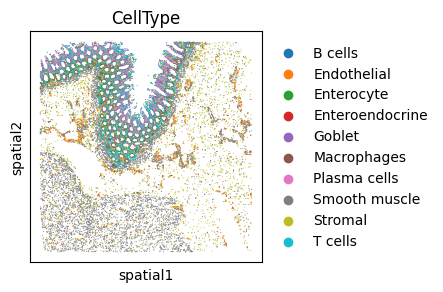

In [10]:
plt.rcParams["figure.figsize"] = (3, 3)
sc.pl.embedding(rna_mapped, basis='spatial', s=2, color=['CellType'])

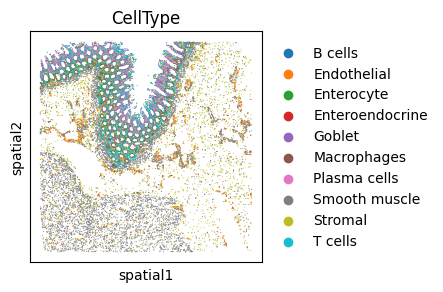

In [11]:
plt.rcParams["figure.figsize"] = (3, 3)
sc.pl.embedding(atac_mapped, basis='spatial', s=2, color=['CellType'])